In [ ]:
import sys, os
# Fix paths so kit.py and data/ are always found from project root
ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline


In [2]:

import numpy as np
import pandas as pd
import kit as erk


In [3]:
ind_return = erk.get_ind_returns()
tmi_return = erk.get_total_market_index_return()

In [4]:
tmi_return

1926-07    0.031375
1926-08    0.028957
1926-09    0.005566
1926-10   -0.028504
1926-11    0.028039
             ...   
2018-08    0.036951
2018-09    0.002108
2018-10   -0.074292
2018-11    0.019003
2018-12   -0.092911
Freq: M, Name: Total Market, Length: 1110, dtype: float64

In [5]:
risk_r = ind_return["2000":][["Steel","Fin","Beer"]]
#Safe Asset

In [6]:
risk_r.shape

(228, 3)

In [7]:
safe_r = pd.DataFrame().reindex_like(risk_r)

In [8]:
safe_r.shape

(228, 3)

In [9]:
safe_r[:] = 0.03/12
start = 1000
floor = 0.8

In [10]:
safe_r

,Steel,Fin,Beer
2000-01,0.0025,0.0025,0.0025
2000-02,0.0025,0.0025,0.0025
2000-03,0.0025,0.0025,0.0025
2000-04,0.0025,0.0025,0.0025
2000-05,0.0025,0.0025,0.0025
...,...,...,...
2018-08,0.0025,0.0025,0.0025
2018-09,0.0025,0.0025,0.0025
2018-10,0.0025,0.0025,0.0025
2018-11,0.0025,0.0025,0.0025


1. Calculuate the Cushion (Asset Value minus Floor Value)
2. Compute an Allocation Safe and Risky Asset -> m * risk budget
3. Recompute the Asset Value based the returns

In [11]:
def compound1(r):
    return (1+r).prod() - 1

def compound2(r):
    return np.exp(np.log(1+r).sum()) - 1

In [12]:
compound1(risk_r)

Steel   -0.051696
Fin      1.773937
Beer     3.361349
dtype: float64

In [13]:
compound2(risk_r)

Steel   -0.051696
Fin      1.773937
Beer     3.361349
dtype: float64

In [14]:
%timeit compound1(risk_r)

418 μs ± 20.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [15]:
%timeit compound2(risk_r)

677 μs ± 135 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## CPPI 

In [16]:
dates = risk_r.index
n_steps = len(dates)


In [17]:
account_value = start
floor_value = start*floor 
m = 3

In [18]:
#Standardize the dataa
account_history = pd.DataFrame().reindex_like(risk_r)
cushion_history = pd.DataFrame().reindex_like(risk_r)
risky_w_history = pd.DataFrame().reindex_like(risk_r)


In [19]:
for step in range(n_steps):
    cushion = (account_value - floor_value)/account_value
    risky_w = m * cushion
    risky_w = np.minimum(risky_w, 1)
    risky_w = np.maximum(risky_w, 0)
    safe_w = 1 - risky_w
    
    risky_alloc = account_value*risky_w
    safe_alloc = account_value*safe_w

    ## udpate the account for this time step
    account_value = risky_alloc*(1 + risk_r.iloc[step])+safe_alloc*(1+ safe_r.iloc[step])

    # saves the value for plot
    cushion_history.iloc[step] = cushion
    risky_w_history.iloc[step] = risky_w
    account_history.iloc[step] = account_value


In [20]:
account_history.head()

,Steel,Fin,Beer
2000-01,984.380000,974.480000,987.320000
2000-02,1023.292876,931.167544,922.971256
2000-03,1047.555176,998.187296,924.835988
2000-04,1042.079009,973.927479,939.993701
2000-05,1007.137753,1001.460033,991.145489


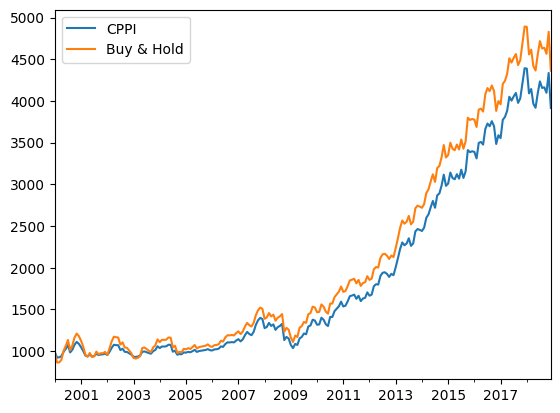

In [21]:
risky_wealth = start*(1+risk_r).cumprod()
ax = account_history["Beer"].plot(label="CPPI")
risky_wealth["Beer"].plot(ax=ax, label="Buy & Hold")
ax.legend()

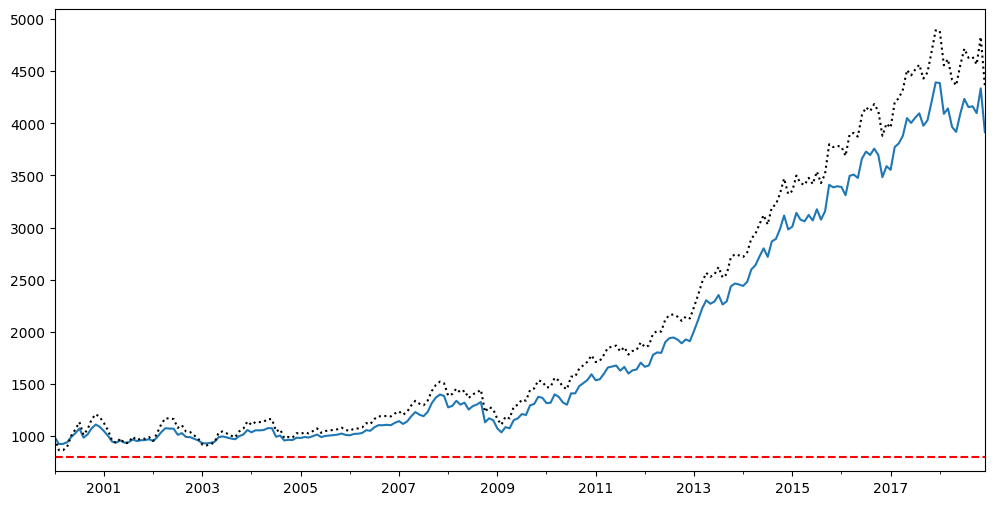

In [22]:
ax = account_history["Beer"].plot(figsize=(12,6))
risky_wealth["Beer"].plot(ax=ax, style="k:")
ax.axhline(y=floor_value, color='r', linestyle="--")

<Axes: >

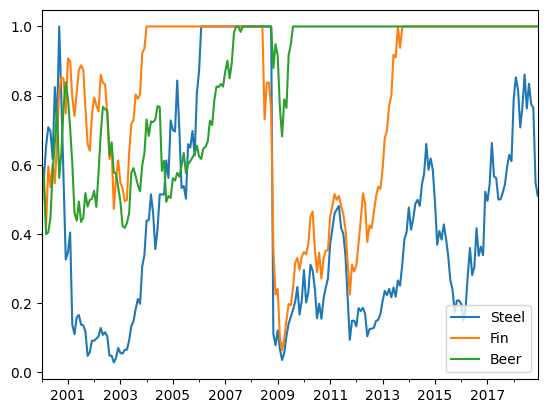

In [23]:
risky_w_history.plot()

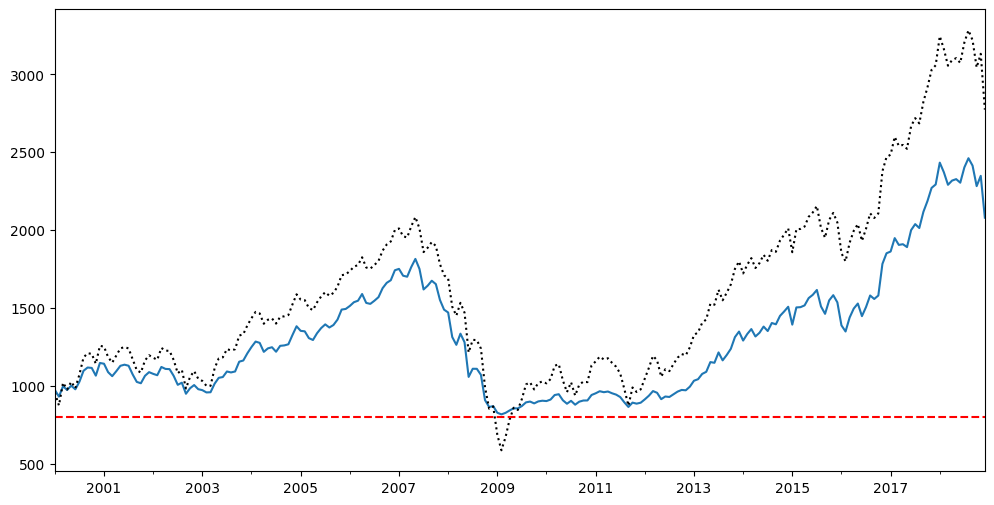

In [24]:
ind = "Fin"
ax = account_history[ind].plot(figsize=(12,6))
risky_wealth[ind].plot(ax=ax, style="k:")
ax.axhline(y=floor_value, color='r', linestyle='--')

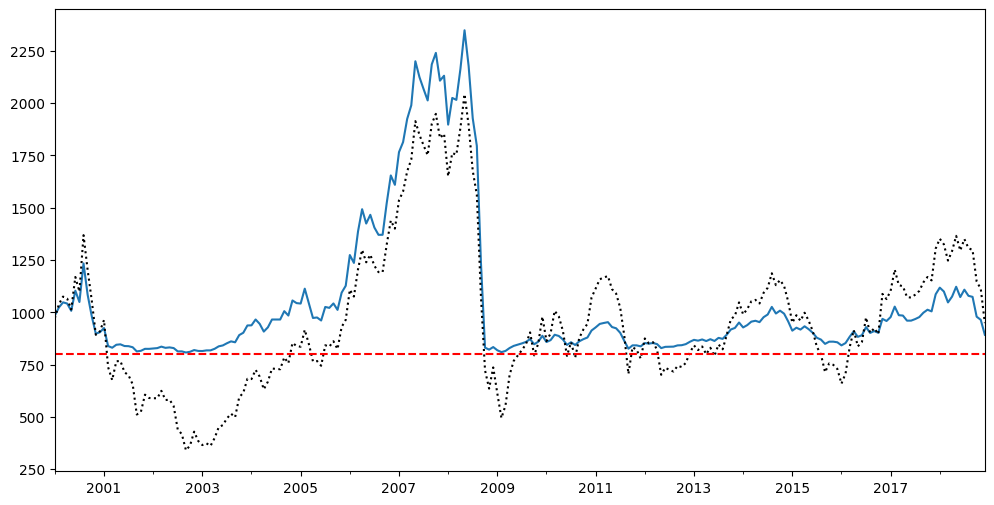

In [25]:
ind = "Steel"
ax = account_history[ind].plot(figsize=(12,6))
risky_wealth[ind].plot(ax=ax, style="k:")
ax.axhline(y=floor_value, color='r', linestyle="--")

In [26]:
btr = erk.run_cppi(tmi_return["2007":])

<Axes: >

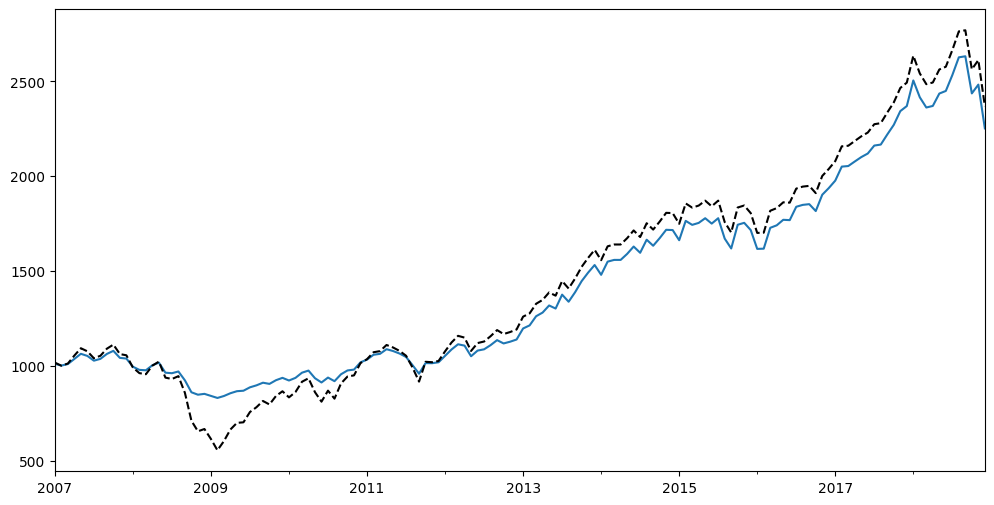

In [32]:
ax = btr["Wealth"].plot(figsize=(12,6), legend=False)
btr["Risky Wealth"].plot(ax=ax, style ="k--", legend=False)

In [37]:
erk.summary_stats(btr["Risky Wealth"].pct_change().dropna())

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Kurtosis,Skew,Sharp Ratio,CVaR 5% (Gaussian),Historic CVaR 5%
R,0.073411,0.150463,0.280618,-0.499943,4.523488,-0.734939,0.280618,0.071592,0.096315


In [39]:
erk.summary_stats(btr["Wealth"].pct_change().dropna())

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Kurtosis,Skew,Sharp Ratio,CVaR 5% (Gaussian),Historic CVaR 5%
R,0.069416,0.100381,0.382052,-0.229683,3.740932,-0.588292,0.382052,0.045678,0.062953


# Drawdown Constraint BackTest

In [40]:
btr = erk.run_cppi(ind_return["2007":][["Steel", "Fin", "Beer"]], drawDown=0.25)

<Axes: >

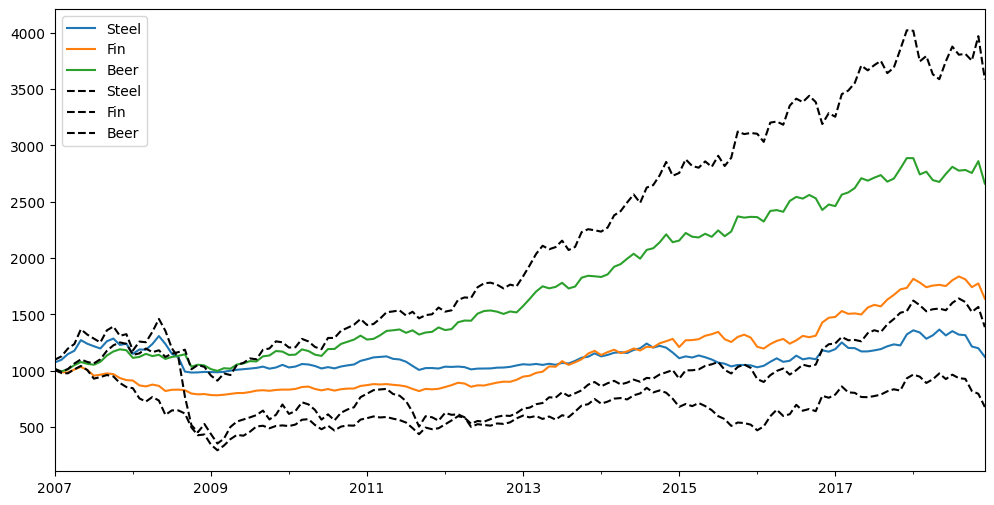

In [41]:
ax = btr["Wealth"].plot(figsize=(12,6))
btr["Risky Wealth"].plot(ax=ax, style="k--")

In [42]:
erk.summary_stats(btr["Risky Wealth"].pct_change().dropna())

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Kurtosis,Skew,Sharp Ratio,CVaR 5% (Gaussian),Historic CVaR 5%
Steel,-0.039660,0.306407,-0.221642,-0.758017,4.782828,-0.459951,-0.221642,0.152288,0.203837
Fin,0.027364,0.212204,-0.012370,-0.718465,4.621401,-0.695200,-0.012370,0.105744,0.149862
Beer,0.111554,0.127971,0.620132,-0.271368,4.650878,-0.670797,0.620132,0.056497,0.077388


In [43]:
erk.summary_stats(btr["Wealth"].pct_change().dropna())

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Kurtosis,Skew,Sharp Ratio,CVaR 5% (Gaussian),Historic CVaR 5%
Steel,0.003784,0.097073,-0.262958,-0.248059,5.220481,-0.441089,-0.262958,0.047371,0.066991
Fin,0.041975,0.085028,0.136964,-0.243626,4.153860,-0.355163,0.136964,0.038342,0.054111
Beer,0.084375,0.086263,0.613413,-0.161186,4.571533,-0.744111,0.613413,0.037937,0.051189
